# Time Series Forecasting using Deep Learning (LSTM)

### 1. Data Collection & Preprocessing:

In [4]:
df = pd.read_csv(r"C:\Users\lenovo\Desktop\weatherHistory.csv")

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  str    
 1   Summary                   96453 non-null  str    
 2   Precip Type               95936 non-null  str    
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  int64  
 8   Visibility (km)           96453 non-null  float64
 9   Loud Cover                96453 non-null  int64  
 10  Pressure (millibars)      96453 non-null  float64
 11  Daily Summary             96453 non-null  str    
dtypes: float64(6), int64(2), str(4)
memory usage: 8.8 MB


In [6]:
df.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251,15.8263,0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259,15.8263,0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204,14.9569,0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269,15.8263,0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259,15.8263,0,1016.51,Partly cloudy throughout the day.


In [7]:
df.isnull().sum()

Formatted Date                0
Summary                       0
Precip Type                 517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0
Wind Bearing (degrees)        0
Visibility (km)               0
Loud Cover                    0
Pressure (millibars)          0
Daily Summary                 0
dtype: int64

In [8]:
df = df.dropna()

In [12]:
df['Formatted Date'] = pd.to_datetime(df['Formatted Date'], utc=True)
df['Formatted Date'] = df['Formatted Date'].dt.tz_localize(None)

df = df.sort_values('Formatted Date')

In [13]:
df = df[['Formatted Date', 'Temperature (C)']]

In [14]:
df.set_index('Formatted Date', inplace=True)

### 2. Normalization:

In [15]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

In [16]:
import numpy as np

X = []
y = []

for i in range(24, len(scaled_data)):
    X.append(scaled_data[i-24:i])  # last 24 hours
    y.append(scaled_data[i])       # next value

X = np.array(X)
y = np.array(y)

In [39]:
# After scaling and sequence creation
X, y = np.array(X), np.array(y)

# IMPORTANT: ensure y is scaled
print("Before split:", y.min(), y.max())  # should be 0–1

# Split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# DEBUG check
print("y_train:", y_train.min(), y_train.max())
print("y_test:", y_test.min(), y_test.max())

Before split: 0.0 1.0
y_train: 0.0 1.0
y_test: 0.1387813877008809 0.9560795606531876


### 3. Sequence Creation:

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input

model = Sequential()

model.add(Input(shape=(X.shape[1], 1)))  
model.add(LSTM(50))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

In [21]:
model.fit(X_train, y_train, epochs=10, batch_size=32)

Epoch 1/10
2398/2398 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 0.0023
Epoch 2/10
2398/2398 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 4.8421e-04
Epoch 3/10
2398/2398 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 3.9365e-04
Epoch 4/10
2398/2398 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 3.7809e-04
Epoch 5/10
2398/2398 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 3.6994e-04
Epoch 6/10
2398/2398 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 3.6003e-04
Epoch 7/10
2398/2398 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 3.4024e-04
Epoch 8/10
2398/2398 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 3.2702e-04
Epoch 9/10
2398/2398 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 3.2241e-04
Epoch 10/10
2398/2398 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 3.2077e-04


In [22]:
print(X_train.shape)
print(y_train.shape)

(76729, 24, 1)
(76729, 1)


### 4. Model Building & Prediction:

In [23]:
predictions = model.predict(X_test)

600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [31]:
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

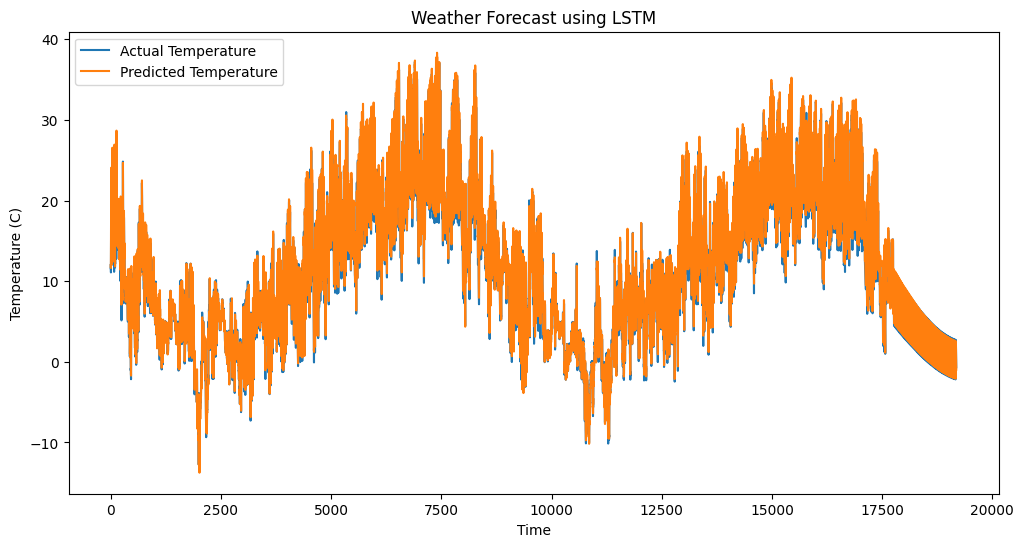

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(y_test, label="Actual Temperature")
plt.plot(predictions, label="Predicted Temperature")

plt.title("Weather Forecast using LSTM")
plt.xlabel("Time")
plt.ylabel("Temperature (C)")
plt.legend()

plt.show()

### 5. Training & Evaluation: 

In [26]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, predictions)
print("MSE:", mse)

MSE: 0.8481000609167221


### 6. Visualization

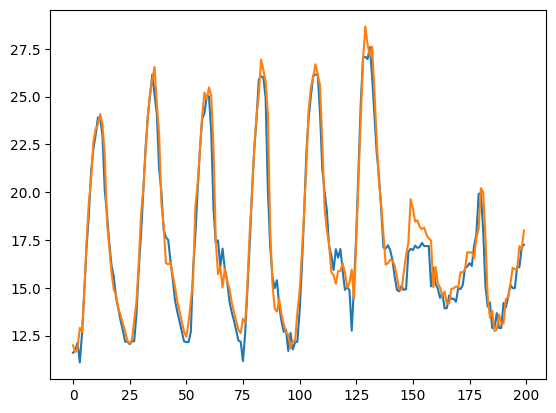

In [27]:
plt.plot(y_test[:200])
plt.plot(predictions[:200])

In [28]:
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/30
2398/2398 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - loss: 3.1479e-04 - val_loss: 205.0089
Epoch 2/30
2398/2398 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 3.1321e-04 - val_loss: 204.9910
Epoch 3/30
2398/2398 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - loss: 3.1149e-04 - val_loss: 204.8996
Epoch 4/30
2398/2398 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - loss: 3.1127e-04 - val_loss: 204.9150
Epoch 5/30
2398/2398 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 3.0920e-04 - val_loss: 204.8919
Epoch 6/30
2398/2398 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 3.0699e-04 - val_loss: 205.1298
Epoch 7/30
2398/2398 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - loss: 3.0502e-04 - val_loss: 204.8636
Epoch 8/30
2398/2398 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 3.0505e-04 - val_loss: 204.9093
Epoch 9/30
2398/2398 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 3.0387e-04 - val_loss: 204.8936
Epoch 10/30
2398/2398 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 3.0113e-04 - val_loss: 204.9247
Epoch 11/30
2398/2398 ━━━━━━━━━━━━━━━━━━━━ 11s 4m

### Checking for Overfitting:

In [40]:
history = model.fit(
    X_train, y_train,
    epochs=40,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/40
2398/2398 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 2.8220e-04 - val_loss: 1.8860e-04
Epoch 2/40
2398/2398 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 2.8162e-04 - val_loss: 1.9441e-04
Epoch 3/40
2398/2398 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 2.8166e-04 - val_loss: 1.8641e-04
Epoch 4/40
2398/2398 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 2.8105e-04 - val_loss: 1.8462e-04
Epoch 5/40
2398/2398 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 2.8044e-04 - val_loss: 2.0274e-04
Epoch 6/40
2398/2398 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 2.7950e-04 - val_loss: 1.8726e-04
Epoch 7/40
2398/2398 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 2.7901e-04 - val_loss: 1.9723e-04
Epoch 8/40
2398/2398 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 2.7890e-04 - val_loss: 1.9729e-04
Epoch 9/40
2398/2398 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 2.7906e-04 - val_loss: 1.8972e-04
Epoch 10/40
2398/2398 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 2.7767e-04 - val_loss: 1.8936e-04
Epoch 11/40
2398/2398 ━━━━━━━

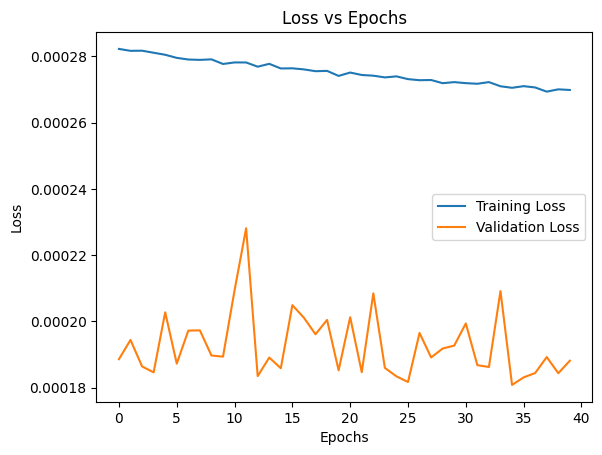

In [41]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

In [42]:
print("Last Training Loss:", history.history['loss'][-1])
print("Last Validation Loss:", history.history['val_loss'][-1])

Last Training Loss: 0.0002698172756936401
Last Validation Loss: 0.00018813868518918753


In [43]:
gap = history.history['val_loss'][-1] - history.history['loss'][-1]
print("Gap:", gap)

Gap: -8.167859050445259e-05
